## **Section 1: Import libraries**

In [1]:
#Numerical computing 
import numpy as np 
#Data maipulation 
import pandas as pd
#Plotting 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 
#Statistical Visualization
import seaborn as sns
#Standard ML library 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

In [2]:
# ── DISPLAY SETTINGS ─────────────────────────────────────────────────────────
# Show all columns when printing DataFrames
pd.set_option('display.max_columns', None)
# Set a clean visual style for all charts
sns.set_theme(style='darkgrid', palette='muted')
# Larger default figure size
plt.rcParams['figure.figsize'] = (14, 5)

## **Section 2: Load and Inspect Data (EDA Part1)**

In [3]:
#load data 
df=pd.read_csv('../data/raw/XAUUSD_raw.csv', parse_dates=['Date'], index_col='Date')
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2022-01-03,1802.51,1821.41,1796.03,1803.97,93230.0
2022-01-04,1802.76,1804.05,1794.52,1803.47,109009.0
2022-01-05,1810.69,1825.77,1797.24,1809.25,150969.0
2022-01-06,1817.17,1824.61,1811.72,1822.04,113866.0
2022-01-07,1819.71,1827.47,1802.38,1820.76,185400.0


In [4]:
print(df.tail())

               Open     High      Low    Close    Volume
Date                                                    
2023-11-27  2151.03  2160.04  2136.32  2152.84   98693.0
2023-11-28  2143.95  2146.89  2143.13  2145.14  159674.0
2023-11-29  2141.69  2162.96  2139.42  2144.22  195598.0
2023-11-30  2141.23  2148.89  2134.97  2137.81  199028.0
2023-12-01  2123.54  2133.46  2120.39  2127.35  133161.0


In [5]:
#Shape 
rows, cols=df.shape
print(f'Dataset has: {rows} rows (trading days)and {cols} columns (features)')

Dataset has: 500 rows (trading days)and 5 columns (features)


In [6]:
#Features Datatypes 
print (df.dtypes)

Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object


In [7]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print('---MISSING VALUES REPORT---')
print(missing_report)

---MISSING VALUES REPORT---
        Missing Count  Missing %
Open                0        0.0
High                0        0.0
Low                 0        0.0
Close               5        1.0
Volume             10        2.0


In [14]:
#Filling missing Close values using linear interpolation
df['Close']=df['Close'].interpolate(method='linear')
#Filling missing volumes using rollling mean
df['Volume']=df['Volume'].fillna(df['Volume'].rolling(5).mean())
df['Volume']=df['Volume'].fillna(0)

In [15]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [16]:
print(df.describe().round(2))

          Open     High      Low    Close     Volume
count   500.00   500.00   500.00   500.00     500.00
mean   1939.01  1949.01  1928.98  1938.97  137535.19
std     135.40   135.56   135.46   135.50   38948.97
min    1732.57  1742.92  1726.98  1735.17       0.00
25%    1798.32  1810.96  1791.67  1797.25  109428.25
50%    1936.48  1946.36  1925.76  1935.51  140203.00
75%    2069.24  2077.00  2058.17  2070.09  166735.75
max    2181.27  2196.30  2180.29  2182.40  199664.00


### **Section  3: EDA Part2**

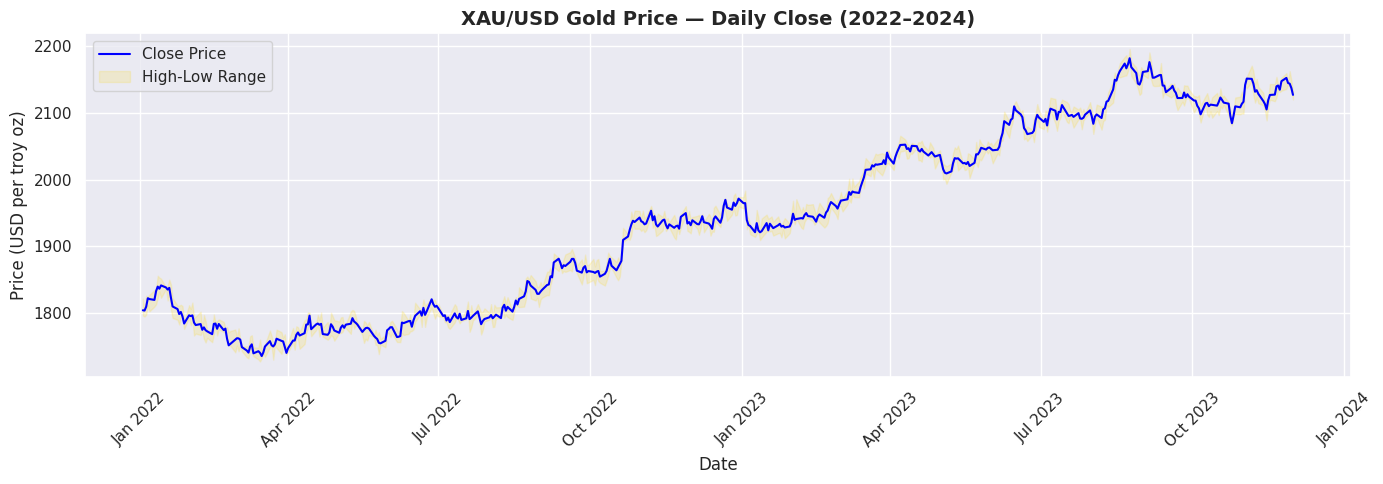

In [18]:
#Chart 1: Price over time - time series plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['Close'], color='blue', linewidth=1.5, label='Close Price')
ax.fill_between(df.index, df['Low'], df['High'], alpha=0.15, color='gold', label='High-Low Range')

ax.set_title('XAU/USD Gold Price — Daily Close (2022–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD per troy oz)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


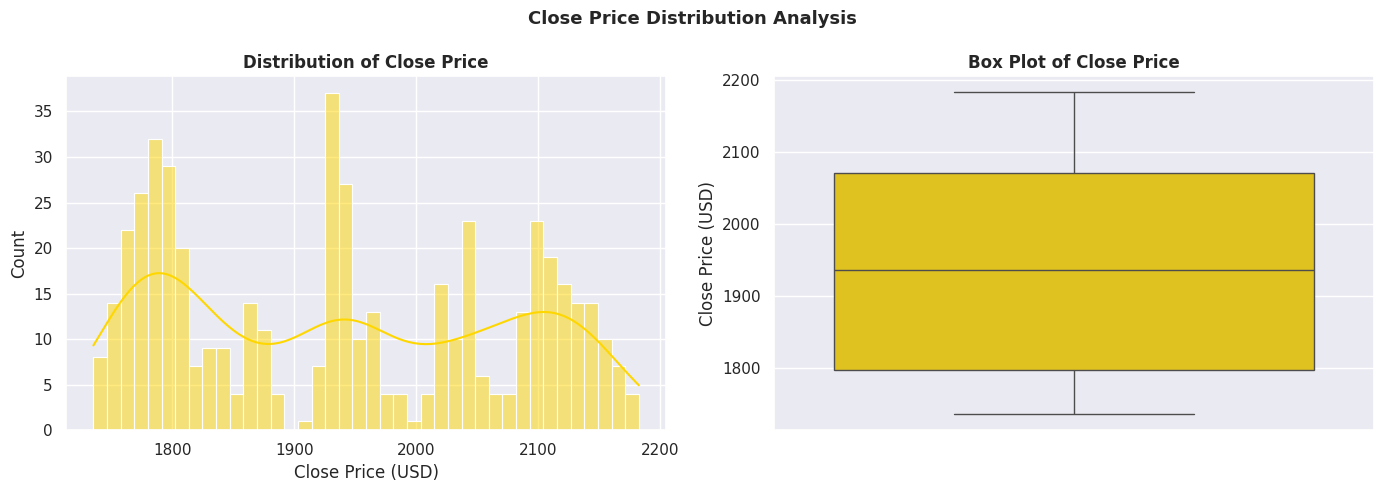

📌 Box plot legend:
   Line in box = median (50th percentile)
   Box edges   = 25th and 75th percentile (the "middle 50%" of data)
   Whiskers    = acceptable range
   Dots        = outliers (values unusually far from the rest)


In [19]:
#Chart 2:Distribution of close price 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df['Close'].dropna(), kde=True, bins=40, color='gold', ax=axes[0])
axes[0].set_title('Distribution of Close Price', fontweight='bold')
axes[0].set_xlabel('Close Price (USD)')

# Box plot — shows median, quartiles, and outliers at a glance
sns.boxplot(y=df['Close'].dropna(), color='gold', ax=axes[1])
axes[1].set_title('Box Plot of Close Price', fontweight='bold')
axes[1].set_ylabel('Close Price (USD)')

plt.suptitle('Close Price Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Box plot legend:')
print('   Line in box = median (50th percentile)')
print('   Box edges   = 25th and 75th percentile (the "middle 50%" of data)')
print('   Whiskers    = acceptable range')
print('   Dots        = outliers (values unusually far from the rest)')

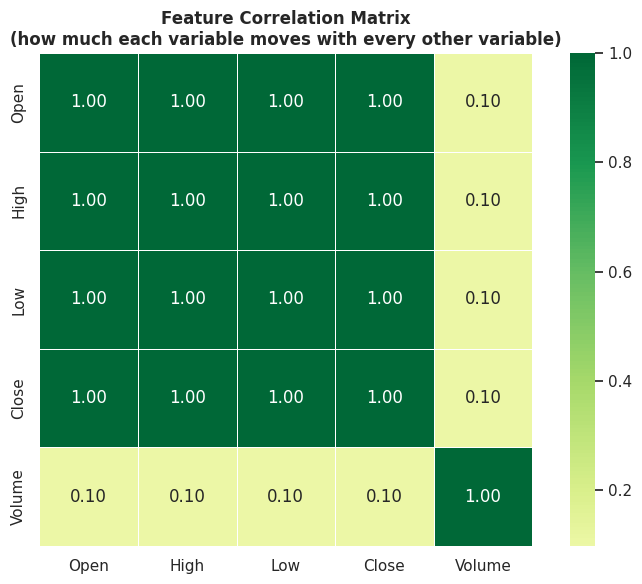

📌 Key insight: Open, High, and Low are highly correlated with Close.
   This makes sense — they are all prices for the same day!
   Volume has a lower correlation — price and trading activity are loosely linked.


In [20]:
#Correlation Heatmap
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,           # show the numbers inside each cell
    fmt='.2f',            # round to 2 decimal places
    cmap='RdYlGn',        # Red = negative, Yellow = neutral, Green = positive
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Feature Correlation Matrix\n(how much each variable moves with every other variable)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Key insight: Open, High, and Low are highly correlated with Close.')
print('   This makes sense — they are all prices for the same day!')
print('   Volume has a lower correlation — price and trading activity are loosely linked.')

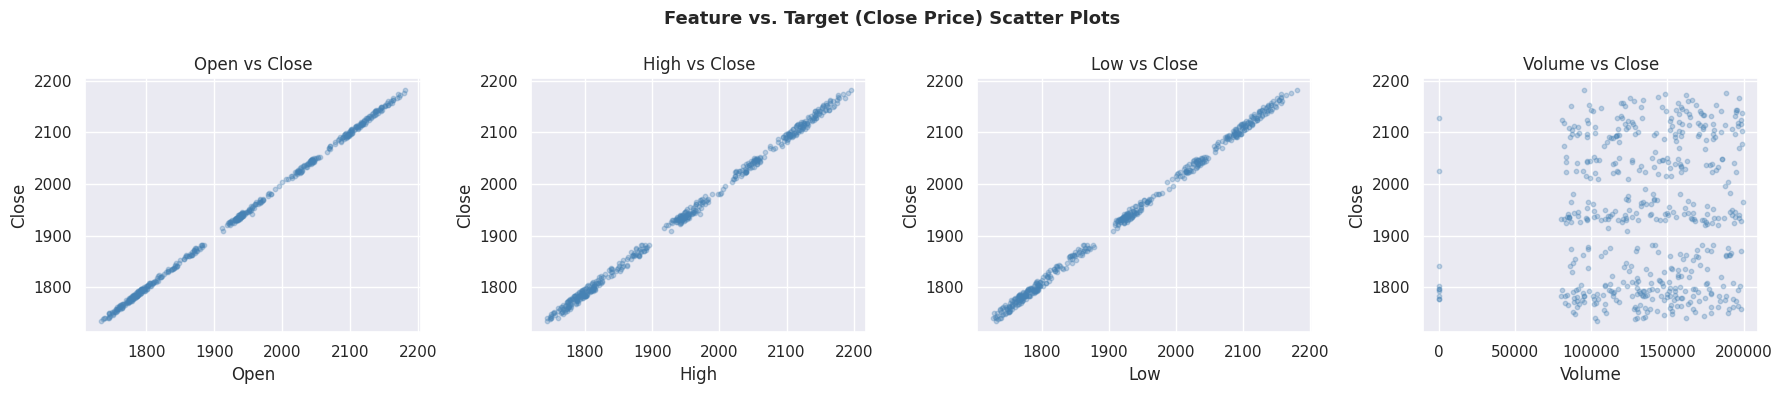

📌 Open, High, Low show tight linear relationships with Close → great features!
   Volume is scattered → weaker predictor on its own.


In [22]:
#Chart 4: Scatter Plots
features = ['Open', 'High', 'Low', 'Volume']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['Close'], alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Close')
    axes[i].set_title(f'{feat} vs Close')

plt.suptitle('Feature vs. Target (Close Price) Scatter Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('📌 Open, High, Low show tight linear relationships with Close → great features!')
print('   Volume is scattered → weaker predictor on its own.')

## **Section 4: Feature engineering**